In [1]:
import os
from tqdm import tqdm
import sys
if not hasattr(sys.modules[__name__], "cwd_changed"):
    os.chdir(os.path.dirname(os.path.dirname(os.path.abspath(__name__))))
    sys.modules[__name__].cwd_changed = True

import warnings 
warnings.filterwarnings("ignore")
import logging
logging.getLogger('pgmpy').setLevel(logging.WARNING)



import pandas as pd
from utils.graph import dag_to_cpdag
import ast
# from metrics.graph import compare_dags
from utils.results import *
from utils.plotting import *

In [2]:
from castle.algorithms import PC
from castle.common import GraphDAG
from castle.metrics import MetricsDAG
from castle.datasets import IIDSimulation, DAG
from castle.algorithms import PC


INFO:root:You can use `os.environ['CASTLE_BACKEND'] = backend` to set the backend(`pytorch` or `mindspore`).
INFO:root:You are using ``pytorch`` as the backend.


INFO:root:Finished synthetic dataset


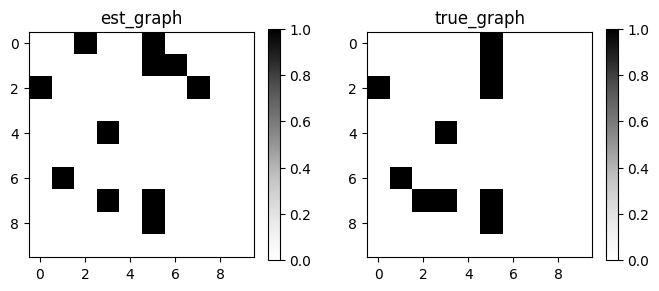

{'fdr': 0.0909, 'tpr': 1.0, 'fpr': 0.0286, 'shd': 2, 'nnz': 11, 'precision': np.float64(0.7273), 'recall': np.float64(0.8), 'F1': np.float64(0.7619), 'gscore': np.float64(0.5)}


In [3]:

weighted_random_dag = DAG.erdos_renyi(n_nodes=10, n_edges=10, 
                                      weight_range=(0.5, 2.0), seed=1)
dataset = IIDSimulation(W=weighted_random_dag, n=2000, method='linear', 
                        sem_type='gauss')
true_causal_matrix, X = dataset.B, dataset.X

# structure learning
pc = PC()
pc.learn(X)

# plot predict_dag and true_dag
GraphDAG(pc.causal_matrix, true_causal_matrix, 'result')

# calculate metrics
mt = MetricsDAG(pc.causal_matrix, true_causal_matrix)
print(mt.metrics)

In [4]:
dataset

### Loading synthetic data

In [5]:
from utils.graph import *
from utils.data import load_csv_with_attrs
from castle.algorithms import Notears
# JPMF Data

base_dir = "data/experiments/RQ1/jpmf_grid/"
# base_dir = "data/experiments/RQ1/binary_grid/"
df_num = 120
df = load_csv_with_attrs(base_dir + f"Data_Graph_{df_num}.csv")
metadata = pd.read_csv(base_dir + f"Metadata_Graph_{df_num}.csv")
true_cpdag = dag_to_cpdag(create_graph(metadata))

df.attrs



{'i': 120,
 'target_mi': 0.15849625007211562,
 'pair_probs': 0.5,
 'syn_cutoff': 0.7}

In [6]:
df_num = df.copy()
# (optional) df_num = df_num.dropna() or impute; gCastle algorithms usually assume no NaNs

# 2) convert to numpy
X = df_num.to_numpy(dtype=np.float64)
cols = df_num.columns.to_list()

# 3) run an algorithm (example: NOTEARS)
nt = Notears()
nt.learn(X)

W = nt.causal_matrix

INFO:root:[start]: n=5000, d=30, iter_=100, h_=1e-08, rho_=1e+16
INFO:root:[iter 0] h=1.820e-01, loss=9.021, rho=1.0e+00
INFO:root:[iter 1] h=1.387e-01, loss=8.050, rho=1.0e+00
INFO:root:[iter 1] h=7.047e-02, loss=8.199, rho=1.0e+01
INFO:root:[iter 1] h=2.450e-02, loss=9.690, rho=1.0e+02
INFO:root:[iter 2] h=1.432e-02, loss=8.212, rho=1.0e+02
INFO:root:[iter 2] h=5.614e-03, loss=8.482, rho=1.0e+03
INFO:root:[iter 3] h=3.489e-03, loss=8.261, rho=1.0e+03
INFO:root:[iter 3] h=1.419e-03, loss=8.403, rho=1.0e+04
INFO:root:[iter 3] h=4.320e-04, loss=9.821, rho=1.0e+05
INFO:root:[iter 4] h=2.365e-04, loss=8.316, rho=1.0e+05
INFO:root:[iter 4] h=8.441e-05, loss=8.400, rho=1.0e+06
INFO:root:[iter 5] h=4.855e-05, loss=8.326, rho=1.0e+06
INFO:root:[iter 5] h=1.828e-05, loss=8.358, rho=1.0e+07
INFO:root:[iter 6] h=1.095e-05, loss=8.332, rho=1.0e+07
INFO:root:[iter 6] h=4.336e-06, loss=8.347, rho=1.0e+08
INFO:root:[iter 7] h=2.702e-06, loss=8.335, rho=1.0e+08
INFO:root:[iter 7] h=1.139e-06, loss=8.

In [7]:
import numpy as np
import networkx as nx

def causal_matrix_to_digraph(W, columns=None, threshold=0.0, weight_attr="weight"):
    """
    Convert a (d x d) causal/adjacency matrix W into a NetworkX DiGraph.

    Parameters
    ----------
    W : array-like, shape (d, d)
        Weighted adjacency matrix where W[i, j] is the weight of i -> j.
    columns : list[str] | None
        Optional node labels (e.g., df.columns). If None, uses 0..d-1.
    threshold : float
        Include edge i->j if abs(W[i,j]) > threshold.
    weight_attr : str
        Edge attribute name to store the weight under.

    Returns
    -------
    G : nx.DiGraph
    """
    W = np.asarray(W)
    if W.ndim != 2 or W.shape[0] != W.shape[1]:
        raise ValueError(f"W must be square (d x d). Got shape {W.shape}.")

    d = W.shape[0]
    nodes = list(columns) if columns is not None else list(range(d))
    if len(nodes) != d:
        raise ValueError(f"columns must have length {d}, got {len(nodes)}.")

    G = nx.DiGraph()
    G.add_nodes_from(nodes)

    # Add edges
    for i in range(d):
        for j in range(d):
            if i == j:
                continue
            w = float(W[i, j])
            if abs(w) > threshold:
                G.add_edge(nodes[i], nodes[j], **{weight_attr: w})

    return G


(<Figure size 1000x800 with 1 Axes>,
 <Axes: title={'center': 'Causal Network Visualization'}>)

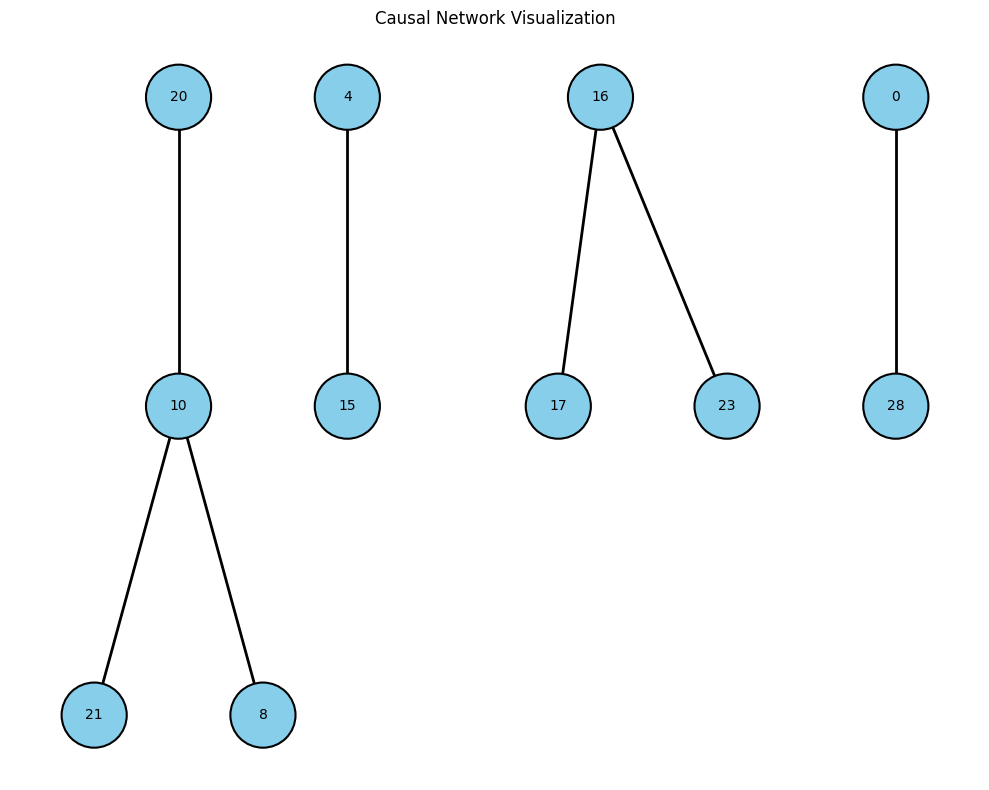

In [8]:
learned_dag = causal_matrix_to_digraph(W, columns=cols, threshold=0.3)
visualize_graph(dag_to_cpdag(learned_dag))

Would create directed cycle by orienting 18->11.
Would create directed cycle by orienting 20->10.


(<Figure size 1000x800 with 1 Axes>,
 <Axes: title={'center': 'Causal Network Visualization'}>)

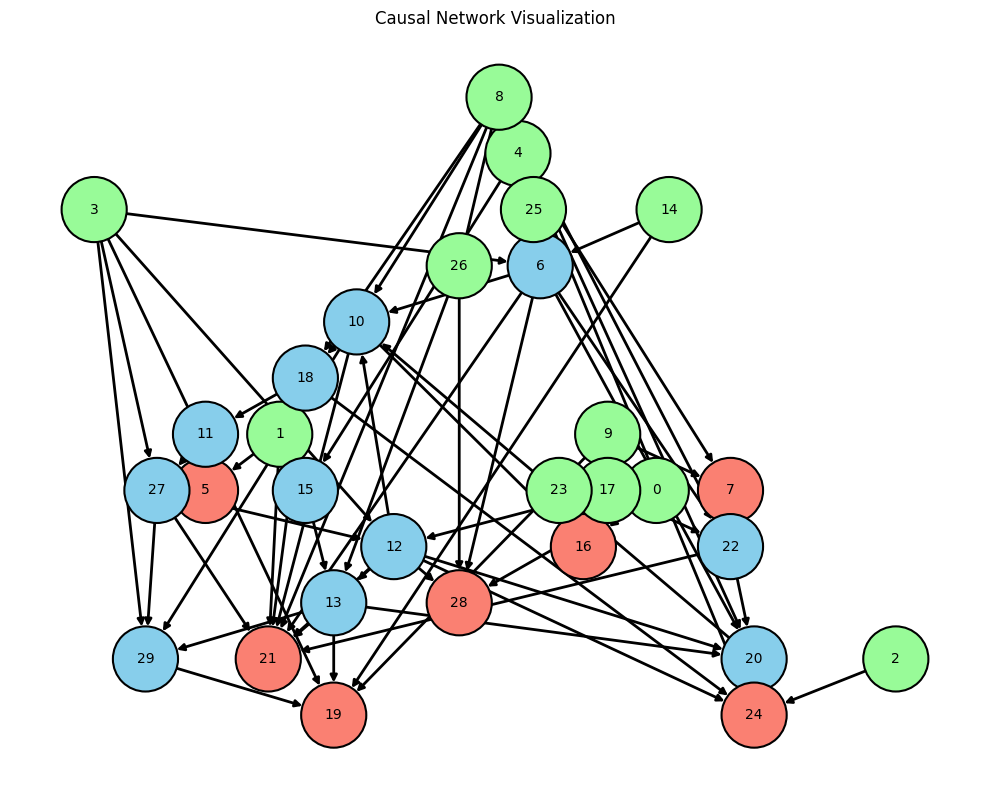

In [9]:
pc = PC()
pc.learn(X)
W = pc.causal_matrix
learned_dag = causal_matrix_to_digraph(W, columns=cols, threshold=0.3)
visualize_graph(dag_to_cpdag(learned_dag))

In [10]:
from metrics.graph import evaluate_colliders, compare_cpdags

In [16]:
evaluate_colliders(metadata, dag_to_cpdag(learned_dag))
# compare_dags_with_labels(dag_to_cpdag(learned_dag), true_cpdag)

Would create directed cycle by orienting 18->11.
Would create directed cycle by orienting 20->10.


{'TP (Found Colliders)': 7,
 'FP (Extra Colliders)': 77,
 'FN (Missing Colliders )': 9,
 'TP (Synergistic Colliders Found)': 7,
 'FN (Missing Synergistic Colliders)': 6,
 'Precision (Collider)': 0.08333333333333333,
 'Recall (Collider)': 0.4375,
 'F1 (Collider)': 0.13999999999999999,
 'Recall (Synergy)': 0.5384615384615384}

In [12]:
metrics = compare_cpdags(dag_to_cpdag(learned_dag), true_cpdag)

Would create directed cycle by orienting 18->11.
Would create directed cycle by orienting 20->10.


In [13]:
metrics

{'n_nodes': 30.0,
 'n_pairs': 435.0,
 'SHD [CPDAG]': 54.0,
 'SHD [Skeleton]': 42.0,
 'Type Confusions [Adjacency]': 12.0,
 'n_true [Adjacency]': 67.0,
 'n_pred [Adjacency]': 41.0,
 'TP [Adjacency]': 33.0,
 'FP [Adjacency]': 8.0,
 'FN [Adjacency]': 34.0,
 'Precision [Adjacency]': 0.8048780487804879,
 'Recall [Adjacency]': 0.4925373134328358,
 'F1 [Adjacency]': 0.611111111111111,
 'n_true [Directed]': 63.0,
 'n_pred [Directed]': 35.0,
 'TP [Directed]': 19.0,
 'FP [Directed]': 16.0,
 'FN [Directed]': 44.0,
 'Precision [Directed]': 0.5428571428571428,
 'Recall [Directed]': 0.30158730158730157,
 'F1 [Directed]': 0.38775510204081637,
 'n_true [Undirected]': 4.0,
 'n_pred [Undirected]': 6.0,
 'TP [Undirected]': 2.0,
 'FP [Undirected]': 4.0,
 'FN [Undirected]': 2.0,
 'Precision [Undirected]': 0.3333333333333333,
 'Recall [Undirected]': 0.5,
 'F1 [Undirected]': 0.4}